#### Dependencies

In [1]:
!uv pip install -e "../.[performance]"
# import mct

Using Python 3.11.14 environment at: /Users/zickers/Research/krastanov_lab/open-source-projects/MCT/.venv
Resolved 7 packages in 17ms                                          
   Building numba==0.63.1                                              
   Building numba==0.63.1                                      
   Building llvmlite==0.46.0
   Building numba==0.63.1                                      
   Building llvmlite==0.46.0
   Building mct @ file:///Users/zickers/Research/krastanov_lab/open-source-proje
   Building numba==0.63.1                                      
   Building llvmlite==0.46.0
   Building mct @ file:///Users/zickers/Research/krastanov_lab/open-source-proje
   Building numba==0.63.1                                      
   Building llvmlite==0.46.0
   Building mct @ file:///Users/zickers/Research/krastanov_lab/open-source-proje
   Building numba==0.63.1                                      
   Building llvmlite==0.46.0
   Building mct @ file:///Users/zickers/Rese

# Amplitude Damping 

$$E_0(\lambda) = \begin{pmatrix} 1 & 0 \\ 0 & \sqrt{1-\lambda} \end{pmatrix}, \quad E_1(\lambda) = \begin{pmatrix} 0 & \sqrt{\lambda} \\ 0 & 0 \end{pmatrix}$$

In [2]:
from mct import apply_channel, probability_symbol, get_density_basis, to_bell_basis, lmatrix, apply_channel_basis, run_markov_experiment, transition_matrix_from_sympy
import sympy as sp

Numba not installed; using pure Python simulation (slower). Install with: pip install numba


State 0


<IPython.core.display.Math object>

State 1


<IPython.core.display.Math object>

State 2


...

State 2:


<IPython.core.display.Math object>

State 3:


<IPython.core.display.Math object>

Total simulation time: 600 μs
Number of steps: 1200
λ value: 0.00249687760253992
dt: 0.5 μs
Simulation completed in 14.56s (0.7M transitions/s)
Asymptotic populations: [0.21712633 0.28434901 0.25028538 0.24823928]


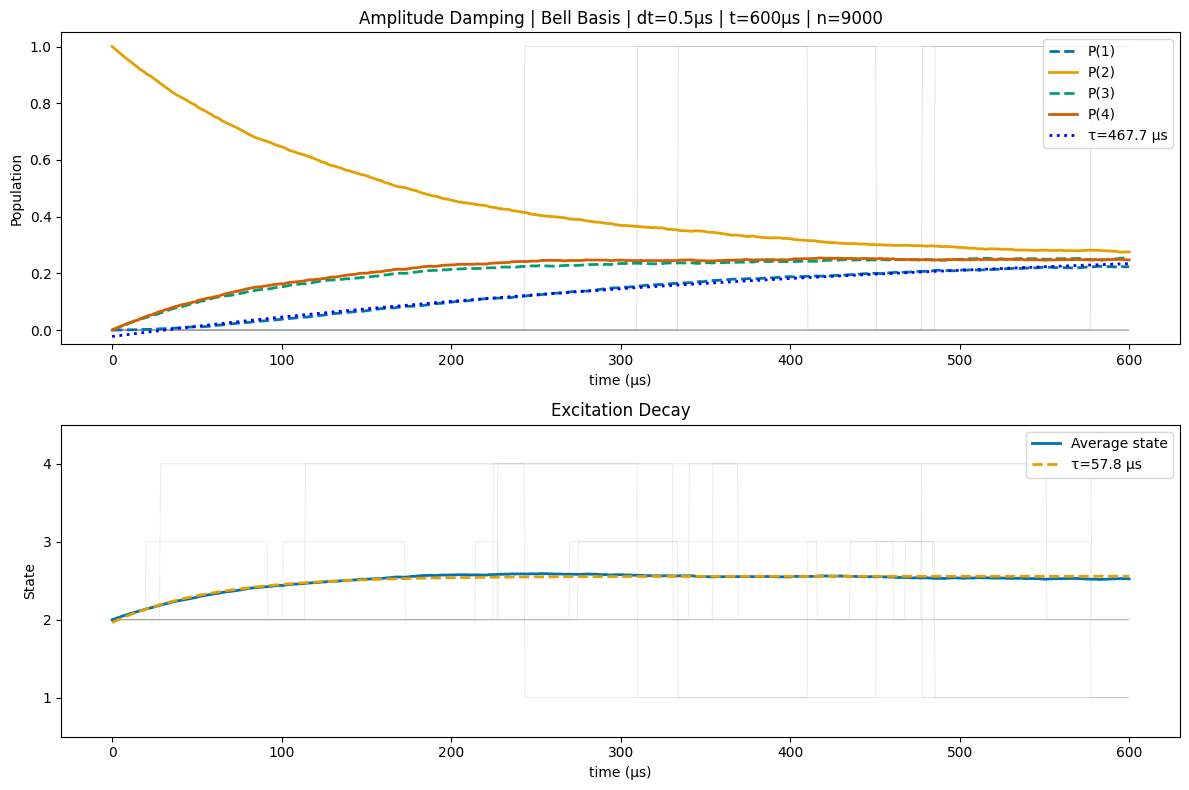

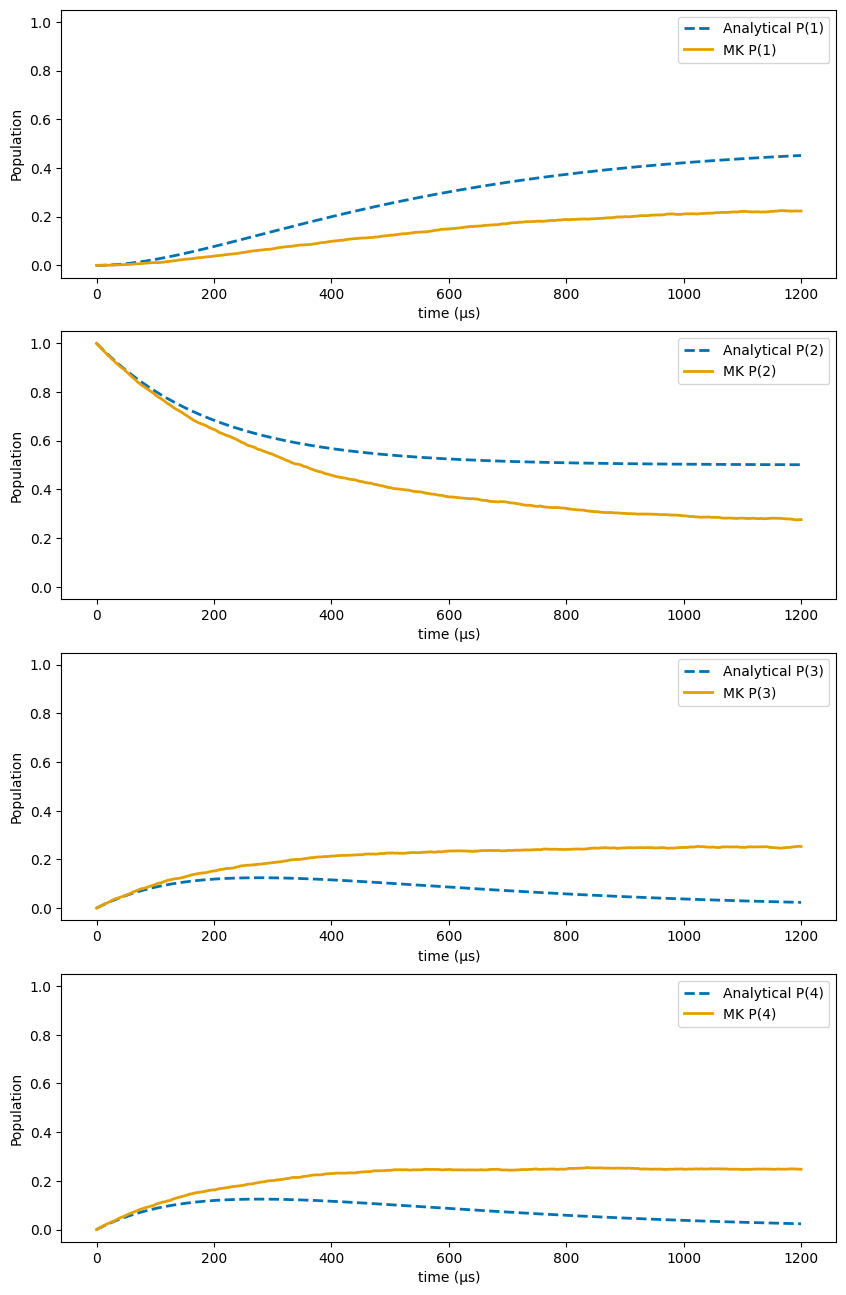

In [9]:

# kraus ops
λ, assumptions = probability_symbol('λ')
E0 = sp.Matrix([[1, 0], [0, sp.sqrt(1 - λ)]])
E1 = sp.Matrix([[0, sp.sqrt(λ)], [0, 0]])
kraus_ops = [E0, E1]
# get 2 qubit kraus ops (E0E0, E0E1, ...), and bring to bell basis
kraus_ops_bell = [
    to_bell_basis(sp.Matrix(sp.kronecker_product(Ei, Ej))) for Ei in kraus_ops for Ej in kraus_ops
]
# Show them
# for i, K in enumerate(kraus_ops_bell):
#     print(f"Kraus operator K_{i}:")
#     display(lmatrix(sp.simplify(K)))
#     print("\n")

basis_states = get_density_basis(2,states="bell",basis="comp")
analytical_basis = get_density_basis(2,states="comp",basis="comp")
rho_finals = apply_channel_basis(basis_states, [E0, E1], symbols=[λ], assumptions=assumptions)

# Go into bell basis
from mct import to_bell_basis
rho_finals_bell = [to_bell_basis(sp.Matrix(rho)) for rho in rho_finals]
print("State transitions in bell basis")
for i,rho in enumerate(rho_finals_bell):
    print(f"State {i}:")
    display(lmatrix(sp.simplify(rho)))

dt = 0.5
t1 = 200 # μs
lambda_val = 1 - sp.exp(-dt / t1)

total_time = 600  # μs - target simulation time
steps = int(total_time / dt)
keep_traj = 50
n_trajectories = 9000
initial_state = 2  # Bell state |Φ+>
print(f"Total simulation time: {total_time} μs")
print(f"Number of steps: {steps}")
print(f"λ value: {lambda_val}")
print(f"dt: {dt} μs")
# print(f"T1 time: {t1} μs")

# Compute analytical transition matrix from density matrices (exact, no sampling needed)
# trans_matrix = transition_matrix_from_sympy(rho_finals, lambda_val)
trans_matrix = transition_matrix_from_sympy(rho_finals_bell, lambda_val)

# Descriptive plot name and save path
plot_name = f"Amplitude Damping | Bell Basis | dt={dt}μs | t={total_time}μs | n={n_trajectories}"
# save_file = "plots/amplitude_damping_comp_basis_state11.png"
save_file = None
kept_trajs, pop_history, asymptotic_pops = run_markov_experiment(
    name=plot_name,
    initial_state=initial_state,
    dt=dt,
    steps=steps,
    n_trajectories=n_trajectories,
    keep_traj=keep_traj,
    # fit_state=initial_state,  # fit decay of initial state
    transition_matrix=trans_matrix,  # Use analytical matrix
    # save_path=save_file,
    # Analytical comparison
    compare_to_analytical_kraus=kraus_ops_bell,
    analytical_init_state=analytical_basis[initial_state-1],
    analytical_pts=steps,
    analytical_symbols={λ: lambda_val}
)


In [4]:
# Get mk chain in code TODO


# Phase Damping

In [10]:
E0 = sp.Matrix([[1, 0], [0, sp.sqrt(1 - λ)]])
E1 = sp.Matrix([[0, 0], [0, sp.sqrt(λ)]])
# get computational basis
basis_states = get_density_basis(2,basis='comp', states='bell') # 2qubit
print("State 1")
for i in range(len(basis_states)):
    display(lmatrix(basis_states[i]))

State 1


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [11]:

rho_finals = apply_channel_basis(basis_states, [E0, E1], symbols=[λ], assumptions=assumptions)


State 0


<IPython.core.display.Math object>

State 1


<IPython.core.display.Math object>

State 2


<IPython.core.display.Math object>

State 3


<IPython.core.display.Math object>

In [12]:
# Go into bell basis
from mct import to_bell_basis
rho_finals_bell = [to_bell_basis(sp.Matrix(rho)) for rho in rho_finals]
rho_finals_bell


⎡⎡1.0 - 0.5⋅λ    0    0  0⎤  ⎡0.5⋅λ       0       0  0⎤  ⎡0  0       0         ↪
⎢⎢                        ⎥  ⎢                        ⎥  ⎢                     ↪
⎢⎢     0       0.5⋅λ  0  0⎥  ⎢  0    1.0 - 0.5⋅λ  0  0⎥  ⎢0  0       0         ↪
⎢⎢                        ⎥, ⎢                        ⎥, ⎢                     ↪
⎢⎢     0         0    0  0⎥  ⎢  0         0       0  0⎥  ⎢0  0  1.0 - 0.5⋅λ    ↪
⎢⎢                        ⎥  ⎢                        ⎥  ⎢                     ↪
⎣⎣     0         0    0  0⎦  ⎣  0         0       0  0⎦  ⎣0  0       0       0 ↪

↪  0  ⎤  ⎡0  0    0         0     ⎤⎤
↪     ⎥  ⎢                        ⎥⎥
↪  0  ⎥  ⎢0  0    0         0     ⎥⎥
↪     ⎥, ⎢                        ⎥⎥
↪  0  ⎥  ⎢0  0  0.5⋅λ       0     ⎥⎥
↪     ⎥  ⎢                        ⎥⎥
↪ .5⋅λ⎦  ⎣0  0    0    1.0 - 0.5⋅λ⎦⎦

Total simulation time: 600 μs
Number of steps: 3000
λ value: 0.00199800133266692
dt: 0.2 μs
Plot saved to: plots/amplitude_damping_bell_basis_state11.png
Simulation completed in 20.02s (0.7M transitions/s)
Asymptotic populations: [0.         0.         0.49884925 0.50115075]


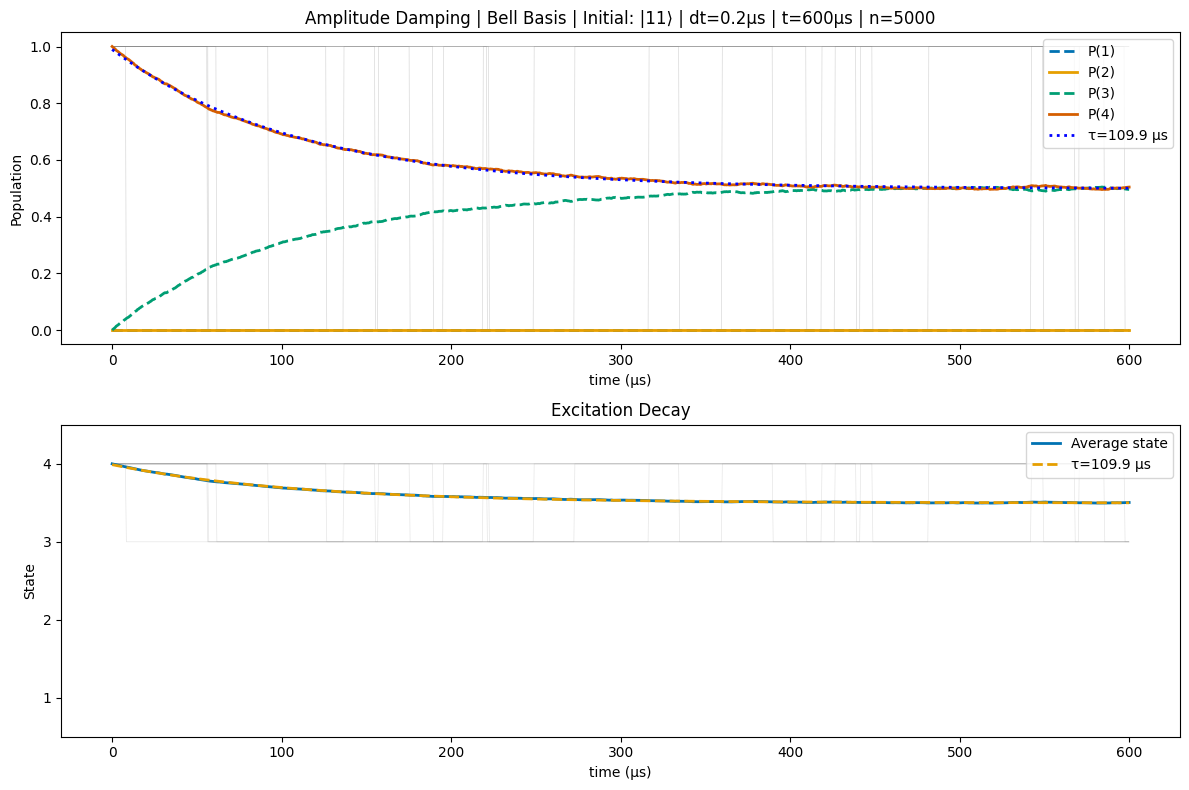

In [13]:

# amplitude damping, bell basis, starting from state 11 (4)

experiment_name = "Amplitude damping (bell basis)"
initial_state = 4
n_trajectories = 5000
keep_traj = 100
# dt = gate_time
dt = 0.2
# dt = 0.1 # μs
t1 = 100 # μs
# use a longer gate for faster decay 
# gate_time = 0.2 # μs

# lambda_val = lambda1_from_t1_gate_time(t1, dt)
lambda_val = 1 - sp.exp(-dt / t1)
# Work backwards from total time to calculate steps

total_time = 600  # μs - target simulation time
steps = int(total_time / dt)

print(f"Total simulation time: {total_time} μs")
print(f"Number of steps: {steps}")
print(f"λ value: {lambda_val}")
print(f"dt: {dt} μs")
# print(f"T1 time: {t1} μs")

# Compute analytical transition matrix from density matrices (exact, no sampling needed)
# trans_matrix = transition_matrix_from_sympy(rho_finals, lambda_val)
trans_matrix = transition_matrix_from_sympy(rho_finals_bell, lambda_val)

# Descriptive plot name and save path
plot_name = f"Amplitude Damping | Bell Basis | Initial: |11⟩ | dt={dt}μs | t={total_time}μs | n={n_trajectories}"
save_file = "plots/amplitude_damping_bell_basis_state11.png"

kept_trajs, pop_history, asymptotic_pops = run_markov_experiment(
    name=plot_name,
    initial_state=initial_state,
    dt=dt,
    steps=steps,
    n_trajectories=n_trajectories,
    keep_traj=keep_traj,
    fit_state=initial_state,  # fit decay of initial state
    state_count=4,
    transition_matrix=trans_matrix,  # Use analytical matrix
    save_path=save_file,
)


# Asymmetric depolarizing channel
Depolarizing channel with px=py = (1-exp(-t/T1))/4, pz = (1-exp(-t/T2))/2 - (1-exp(-t/T1))/2

In [3]:
# Pauli ops
I = sp.Matrix([[1, 0],[0, 1]])
X = sp.Matrix([[0, 1],[1, 0]])
Y = sp.Matrix([[0, -sp.I],[sp.I, 0]])
Z = sp.Matrix([[1, 0],[0, -1]])

# Kraus ops (p_σ I, p_x X, p_y Y, p_z Z), p_σ = 1 - p_x - p_y - p_z
p_x, assumptions_x = probability_symbol('p_x')
p_y, assumptions_y = probability_symbol('p_y')
p_z, assumptions_z = probability_symbol('p_z')
assumptions = assumptions_x & assumptions_y & assumptions_z
p_sigma = 1 - p_x - p_y - p_z   
K0 = sp.sqrt(p_sigma) * I
K1 = sp.sqrt(p_x) * X
K2 = sp.sqrt(p_y) * Y
K3 = sp.sqrt(p_z) * Z
kraus_ops = [K0, K1, K2, K3]

    


basis_states = get_density_basis(2,basis='comp', states='bell') # 2qubit

rho_finals = apply_channel_basis(basis_states, kraus_ops, symbols=[p_x, p_y, p_z], assumptions=assumptions)


State 0


<IPython.core.display.Math object>

State 1


<IPython.core.display.Math object>

State 2


<IPython.core.display.Math object>

State 3


<IPython.core.display.Math object>

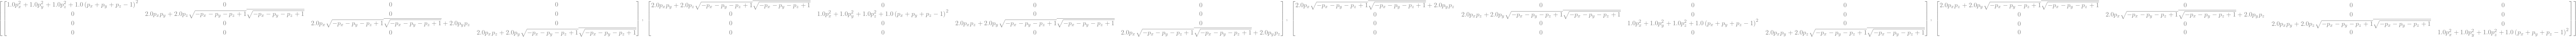

In [4]:
from mct import to_bell_basis
rho_finals_bell = [to_bell_basis(sp.Matrix(rho)) for rho in rho_finals]
rho_finals_bell

In [5]:
import numpy as np


# ADC experiment: Asymmetric depolarizing channel simulation
# Using T1/T2 parameterization: px=py = (1-exp(-t/T1))/4, pz = (1-exp(-t/T2))/2 - (1-exp(-t/T1))/4

dt = 0.5  # μs
t1 = 200  # μs
t2 = 100  # μs (T2 <= 2*T1 physically)


ADC Parameters:
  T1 = 200 μs, T2 = 100 μs, dt = 0.5 μs
  p_x = 0.000624, p_y = 0.000624, p_z = 0.001870
  Total time: 600 μs, Steps: 1200
Simulation completed in 14.08s (0.8M transitions/s)
Asymptotic populations: [0.24824066 0.25309405 0.25288243 0.24578285]


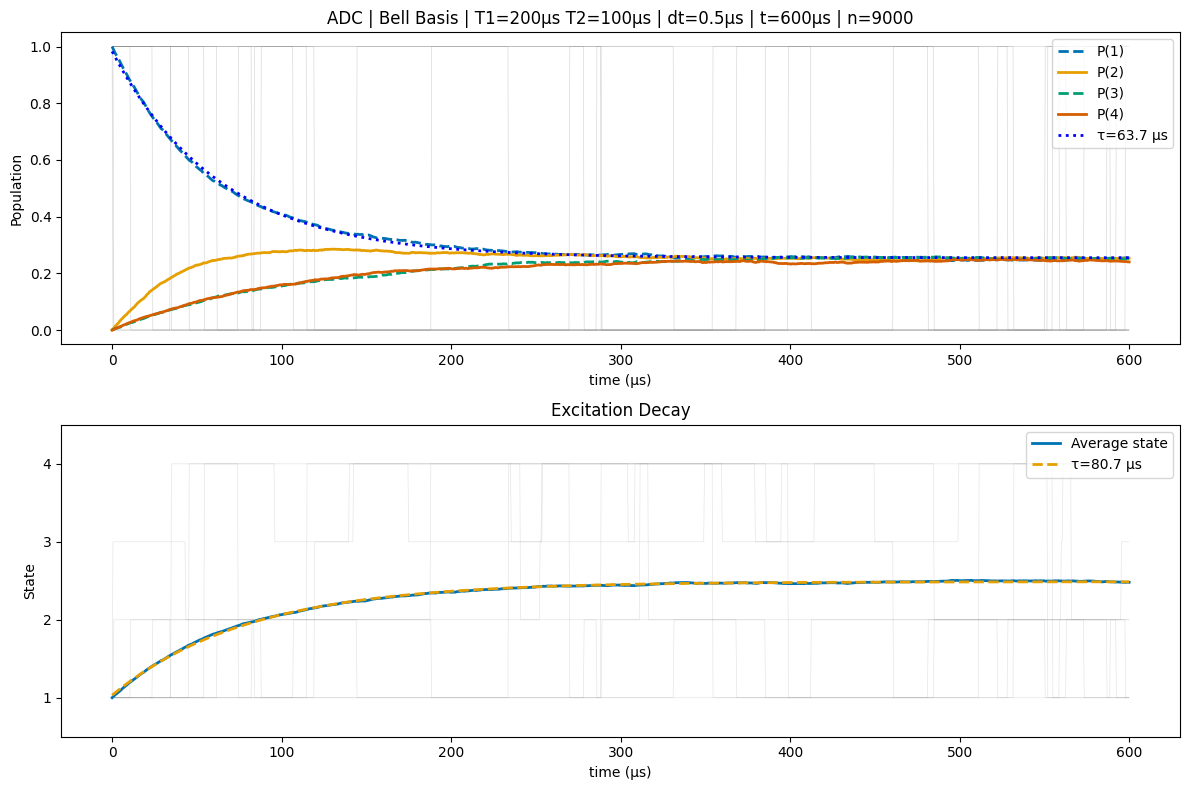

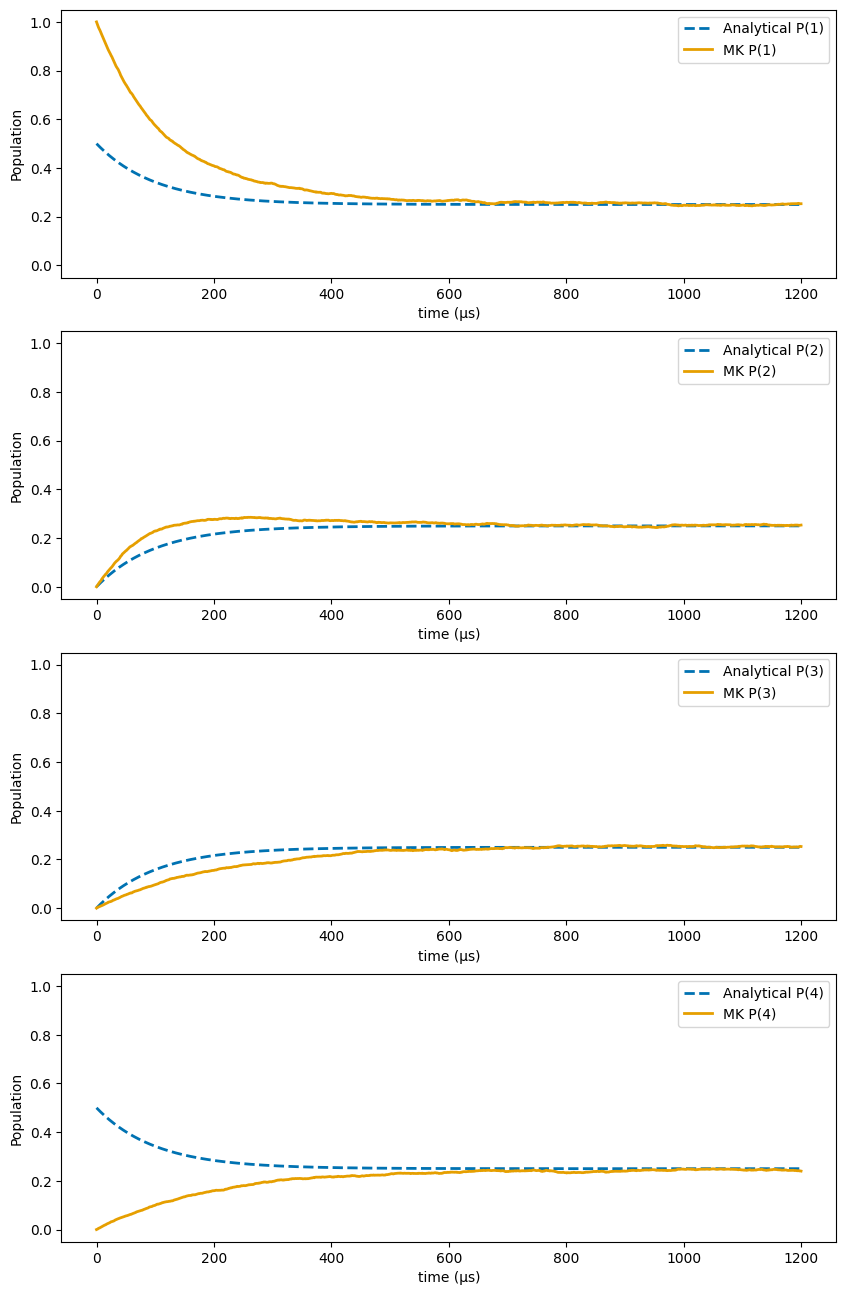

In [6]:

# Compute probabilities from T1/T2
p_x_val = (1 - np.exp(-dt / t1)) / 4
p_y_val = (1 - np.exp(-dt / t1)) / 4
p_z_val = (1 - np.exp(-dt / t2)) / 2 - (1 - np.exp(-dt / t1)) / 4

total_time = 600  # μs
steps = int(total_time / dt)
n_trajectories = 9000
keep_traj = 50
initial_state = 1  # Bell state |Φ+>

print(f"ADC Parameters:")
print(f"  T1 = {t1} μs, T2 = {t2} μs, dt = {dt} μs")
print(f"  p_x = {p_x_val:.6f}, p_y = {p_y_val:.6f}, p_z = {p_z_val:.6f}")
print(f"  Total time: {total_time} μs, Steps: {steps}")

# Compute analytical transition matrix from Bell-basis density matrices
trans_matrix = transition_matrix_from_sympy(
    rho_finals_bell, 
    {p_x: p_x_val, p_y: p_y_val, p_z: p_z_val}
)

# Build 2-qubit Kraus operators in Bell basis for analytical comparison
kraus_ops_2q_bell = [
    to_bell_basis(sp.Matrix(sp.kronecker_product(Ki, Kj))) 
    for Ki in kraus_ops for Kj in kraus_ops
]

plot_name = f"ADC | Bell Basis | T1={t1}μs T2={t2}μs | dt={dt}μs | t={total_time}μs | n={n_trajectories}"

kept_trajs, pop_history, asymptotic_pops = run_markov_experiment(
    name=plot_name,
    initial_state=initial_state,
    dt=dt,
    steps=steps,
    n_trajectories=n_trajectories,
    keep_traj=keep_traj,
    transition_matrix=trans_matrix,
    compare_to_analytical_kraus=kraus_ops_2q_bell,
    analytical_init_state=basis_states[initial_state - 1],
    analytical_pts=steps,
    analytical_symbols={p_x: p_x_val, p_y: p_y_val, p_z: p_z_val}
)